In [42]:
#Importing the modules required for the problem
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import seaborn as sns

In [25]:
#Uploading the dataset
df= pd.read_csv('bs140513_032310.csv')
#df.describe(include='all')
df.head()


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [26]:
#Checking for missing values or the values
missing_values = df.isnull().sum()
missing_values
df.describe()

,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


In [28]:
#Defining the variables
X = df.drop('fraud', axis=1)
y = df['fraud']



In [36]:

#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y,
random_state = 42)
print(X_train.shape)
print(X_test.shape)


(475714, 9)
(118929, 9)


In [39]:
#Using Label encoder to convert the datatypes
label_encoder = {}
for col in X_train.select_dtypes(include = ['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])

    #Transform test data (handle unseen values safely)
    X_test[col] = X_test[col].map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )

    label_encoders[col] = le

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

In [44]:
print("Original training shape:", X_train.shape)
print("Resampled training shape:", X_train_resampled.shape)
print("Test shape:", X_test_scaled.shape)

Original training shape: (475714, 9)
Resampled training shape: (939908, 9)
Test shape: (118929, 9)


In [64]:
#Using Random Forest Classifier(RFC) for the model selection
model1 =RandomForestClassifier(n_estimators= 100, random_state=42)
model1.fit(X_train_resampled, y_train_resampled)



RandomForestClassifier(random_state=42)

In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model1,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())

Cross-validation F1 scores: [0.99620438 0.99651634 0.99650492 0.99645215 0.99653752]
Mean F1 score: 0.9964430635168112


In [66]:
feature_importance = pd.Series(model1.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

amount         0.370954
category       0.356432
merchant       0.219668
customer       0.017510
step           0.015681
age            0.014476
gender         0.005278
zipcodeOri     0.000000
zipMerchant    0.000000
dtype: float64


In [67]:
y_prob = model1.predict_proba(X_test_scaled)[:, 1]

# Custom threshold (example: 0.3)
y_pred1 = (y_prob > 0.3).astype(int)

In [68]:
#Computing the evaluation metrics
acc = accuracy_score(y_test, y_pred1) #Accuracy score for RFC
f1 = f1_score(y_test, y_pred1)#F1 score score for RFC
c_report = classification_report(y_test, y_pred1) #Classification report score for RFC


In [69]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred1)
recall = recall_score(y_test, y_pred1)



In [70]:
#Receiver Operating Characteristic
roc = roc_auc_score(y_test, y_prob)
tpr, fpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(tpr,fpr)


In [71]:
#Confusion Matrix
confusion_mtx= confusion_matrix(y_test, y_pred1)

In [72]:
#Printing out the evaluation metrics
#print('Accuracy Score: ', acc)
print('F1 score: ', f1)
print('Roc: ', roc)
print('Classification Report:')
print(c_report)

F1 score:  0.6752049180327869
Roc:  0.9938500566483291
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    117489
           1       0.53      0.92      0.68      1440

    accuracy                           0.99    118929
   macro avg       0.77      0.95      0.83    118929
weighted avg       0.99      0.99      0.99    118929



Text(0.5, 1.0, 'Confusion Matrix for RFC')

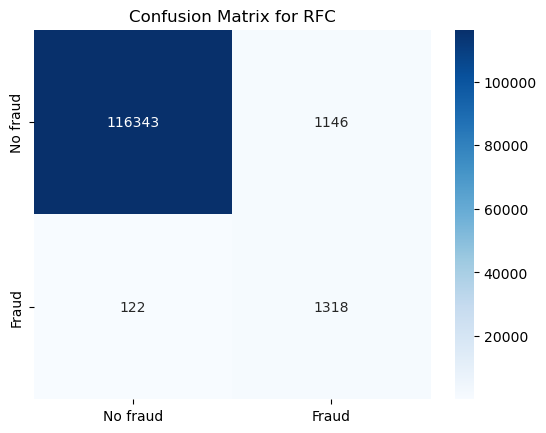

In [73]:
#Confusion Matrix Representation
18
sns.heatmap(confusion_mtx, annot = True, fmt='d', cmap='Blues', 
            xticklabels=['No fraud','Fraud'], 
            yticklabels=['No fraud', 'Fraud'])
plt.title('Confusion Matrix for RFC')


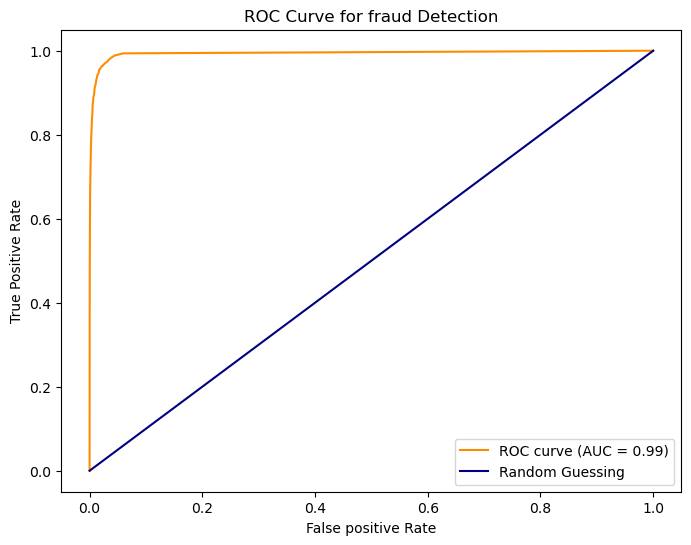

In [74]:
#Plotting the ROC curve
plt.figure(figsize = (8,6))
plt.plot(tpr, fpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', label='Random Guessing')
plt.xlabel('False positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for fraud Detection')
plt.legend(loc = 'lower right')
plt.show()


In [76]:
#Setting up the model for Logistic Regression
model2 = LogisticRegression(random_state = 42)
model2.fit(X_train_resampled, y_train_resampled)


LogisticRegression(random_state=42)

In [77]:
#Predicting the values
y_pred2 = model2.predict(X_test_scaled)


In [78]:
#Evaluation metrics
accuracy2 = accuracy_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)


In [79]:
#Print the Evaluation metrics
print('Accuracy of Logistic Regression: ', accuracy2)
print('F1 score for Logistic Regression: ', f12)
print('Classification Report:')
print(classification_report(y_test, y_pred2))

Accuracy of Logistic Regression:  0.9524758469338849
F1 score for Logistic Regression:  0.3068432671081678
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    117489
           1       0.19      0.87      0.31      1440

    accuracy                           0.95    118929
   macro avg       0.59      0.91      0.64    118929
weighted avg       0.99      0.95      0.97    118929

